# SAM2Mice Bootstrapping Video Predictor

This notebook demonstrates bootstrapped video segmentation for long videos split into frame batches.

Typical flow:

1. Extract batched frame folders.
2. Annotate one or more batch folders with either `labelme <batch_dir>` or `launch_annotator`.
3. Run bootstrapping inference using the saved manual prompts.
4. Preview the output video.


## 0. Imports and Environment


In [1]:
import sys
import os

# Pick the GPU before importing / initializing CUDA.
os.environ["CUDA_VISIBLE_DEVICES"] = "2"

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
%matplotlib inline
from PIL import Image

# Make the repository importable when this notebook is run from notebooks_SAM2-MICE/.
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from SAM2_Mice.segmentation import VideoSegmentationInference, BootstrappingVideoSegmentationInference
from SAM2_Mice.utils import launch_annotator


In [2]:
# Select the compute device and enable the standard SAM2 mixed-precision settings.
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

if device.type == "cuda":
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    # TF32 improves throughput on Ampere+ GPUs with little practical impact here.
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
elif device.type == "mps":
    print(
        "\nSupport for MPS devices is preliminary. SAM 2 is trained with CUDA and might "
        "give numerically different outputs and sometimes degraded performance on MPS."
    )


import glob
import math


def show_masked_video(video_path, vis_frame_stride=100):
    # Display every Nth frame from a saved masked video inside the notebook.
    cap = cv2.VideoCapture(video_path)
    frame_idx = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx % vis_frame_stride == 0:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            plt.figure(figsize=(6, 4))
            plt.imshow(frame_rgb)
            plt.axis("off")
            plt.title(f"Frame {frame_idx}")
            plt.show()
            plt.close("all")

        frame_idx += 1

    cap.release()


def show_bootstrap_masks(save_dir, max_per_type=20):
    """Display all prompt and bootstrapping mask visualizations from a run_bootstrapping() output directory.

    Image categories discovered automatically:
      predictor_N_frame*.jpg        — manual point prompt used to seed batch N
      predictor_N_mask_frame*.jpg   — bootstrapped mask carried from batch N-1 into N
      predictor_N_yolo_*.jpg        — YOLO-detection prompt used to seed batch N
      mask_frame*.jpg               — manual mask prompt (mask prompt_type)
      prompt_masks/*.jpg            — rasterised annotation mask prompts
    """
    categories = {
        "Manual point prompt (per batch)": sorted(
            glob.glob(os.path.join(save_dir, "predictor_*_frame*.jpg"))
        ),
        "Bootstrapped mask (cross-batch handoff)": sorted(
            glob.glob(os.path.join(save_dir, "predictor_*_mask_frame*.jpg"))
        ),
        "YOLO detection prompt": sorted(
            glob.glob(os.path.join(save_dir, "predictor_*_yolo_*.jpg"))
        ),
        "Manual mask prompt": sorted(
            glob.glob(os.path.join(save_dir, "mask_frame*.jpg"))
        ),
    }
    pm_dir = os.path.join(save_dir, "prompt_masks")
    if os.path.exists(pm_dir):
        categories["Annotated mask prompt"] = sorted(glob.glob(os.path.join(pm_dir, "*.jpg")))

    categories = {k: v for k, v in categories.items() if v}

    if not categories:
        print(f"No bootstrapping visualization images found in {save_dir}")
        return

    for category, paths in categories.items():
        paths = paths[:max_per_type]
        n = len(paths)
        cols = min(n, 4)
        rows = math.ceil(n / cols)
        fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows), squeeze=False)
        fig.suptitle(category, fontsize=12, fontweight="bold")
        for idx, path in enumerate(paths):
            r, c = divmod(idx, cols)
            axes[r][c].imshow(np.array(Image.open(path)))
            axes[r][c].set_title(os.path.basename(path), fontsize=7)
            axes[r][c].axis("off")
        for idx in range(n, rows * cols):
            r, c = divmod(idx, cols)
            axes[r][c].axis("off")
        plt.tight_layout()
        plt.show()
        plt.close("all")

using device: cuda


## 1. Download Demo Data and Set Data Root

Download the demo video and pre-made prompt annotations from Google Drive and set `VIDEO_ROOT_DIR`.

Skip this section if you already have the data locally.

In [ ]:
import os
import gdown

# Root directory where demo data will be stored.
VIDEO_ROOT_DIR = "/mnt/nas02/LAR/pico/data_release/SAM2Mice_demo_data/"

# --- 3_bootstrapping/openfield_five_mouse.mp4 ---
boot_dir = os.path.join(VIDEO_ROOT_DIR, "3_bootstrapping")
os.makedirs(boot_dir, exist_ok=True)
boot_video = os.path.join(boot_dir, "openfield_five_mouse.mp4")
if not os.path.exists(boot_video):
    gdown.download(
        "https://drive.google.com/uc?id=15-LwCyA8UVK77QNogFjSOT-EUOYCGDNh",
        boot_video,
        quiet=False,
    )
    print(f"Downloaded: {boot_video}")
else:
    print(f"Already exists: {boot_video}")

# --- Pre-made prompt JSONs for batch_1 ---
# LabelMe annotation files that seed the bootstrapping inference at batch 1.
# Download the whole folder from Google Drive into batch_1/.
batch1_dir = os.path.join(boot_dir, "openfield_five_mouse", "batch_1")
os.makedirs(batch1_dir, exist_ok=True)
existing_jsons = [f for f in os.listdir(batch1_dir) if f.endswith(".json")]
if not existing_jsons:
    gdown.download_folder(
        "https://drive.google.com/drive/folders/12QwySXnKy7u_QhSaFpvStWXY1cLvO_Wr?usp=drive_link",
        output=batch1_dir,
        quiet=False,
        use_cookies=False,
    )
    print(f"Downloaded prompt JSONs to: {batch1_dir}")
else:
    print(f"Prompt JSONs already present in: {batch1_dir}")

Downloading...
From (original): https://drive.google.com/uc?id=1aGAuVYLZles3dsMTudHFOiHzkPUq2LOR
From (redirected): https://drive.google.com/uc?id=1aGAuVYLZles3dsMTudHFOiHzkPUq2LOR&confirm=t&uuid=f3efecd7-c284-45a3-9c66-c34a1e3a0a90
To: /mnt/nas02/LAR/pico/data_release/SAM2Mice_demo_data/3_bootstrapping/openfield_five_mouse.mp4
100%|██████████| 302M/302M [01:35<00:00, 3.16MB/s] 


Downloaded: /mnt/nas02/LAR/pico/data_release/SAM2Mice_demo_data/3_bootstrapping/openfield_five_mouse.mp4


Retrieving folder contents


Processing file 1MWBhI2JCRiTwbcf8htcCn3mWMrJEkqj0 00000.json


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1MWBhI2JCRiTwbcf8htcCn3mWMrJEkqj0
To: /mnt/nas02/LAR/pico/data_release/SAM2Mice_demo_data/3_bootstrapping/openfield_five_mouse/batch_1/00000.json
100%|██████████| 318k/318k [00:01<00:00, 194kB/s]

Downloaded prompt JSONs to: /mnt/nas02/LAR/pico/data_release/SAM2Mice_demo_data/3_bootstrapping/openfield_five_mouse/batch_1



Download completed


## 2. Model and Data Configuration

`frame_interval` in the bootstrapping run should match `BATCH_SIZE` used during extraction.

In [4]:
model_cfg = "../sam2/configs/sam2.1/sam2.1_hiera_b+.yaml"
checkpoint_path = "../checkpoints/SAM2_Mice_base_plus.pt"

VIDEO_PATH = VIDEO_ROOT_DIR + "3_bootstrapping/openfield_five_mouse.mp4"
BATCH_SIZE = 1000
BOOTSTRAP_SAVE_DIR = VIDEO_ROOT_DIR + "3_bootstrapping/openfield_five_mouse_seg"

SAM2_mice_boots_predictor = BootstrappingVideoSegmentationInference(
    model_cfg,
    checkpoint_path=checkpoint_path,
)

False


## 3. Extract Bootstrapping Frame Batches

This creates batch folders such as `batch_1`, `batch_2`, and so on. If the folders already exist, you can skip this cell and set `batch_dirs` manually.

In [5]:
batch_dirs = SAM2_mice_boots_predictor.extract_bootstrapping_frames(
    video_path=VIDEO_PATH,
    batch_size=BATCH_SIZE,
    batch_save_dir="",
)

batch_dirs[:3], len(batch_dirs)


Extracting 9100 frames from /mnt/nas02/LAR/pico/data_release/SAM2Mice_demo_data/3_bootstrapping/openfield_five_mouse.mp4


Processing frames:   0%|          | 0/9100 [00:00<?, ?frame/s]

Processing frames: 100%|██████████| 9100/9100 [00:28<00:00, 322.79frame/s]


(['/mnt/nas02/LAR/pico/data_release/SAM2Mice_demo_data/3_bootstrapping/openfield_five_mouse/batch_1',
  '/mnt/nas02/LAR/pico/data_release/SAM2Mice_demo_data/3_bootstrapping/openfield_five_mouse/batch_2',
  '/mnt/nas02/LAR/pico/data_release/SAM2Mice_demo_data/3_bootstrapping/openfield_five_mouse/batch_3'],
 10)

## 4. Annotate a Batch *(optional — skip if using downloaded prompts)*

**Default (recommended for the demo):** Section 1 already downloaded pre-made LabelMe JSON files into `batch_1/`. You can skip this section and go straight to section 5.

**Create your own prompts:** Choose one batch folder, annotate it with one of the tools below, then continue to section 5.

1. **LabelMe desktop GUI**: runs `labelme <batch_dir>`. Requires a graphical desktop / X11 forwarding.
2. **SAM2-Mice browser annotator**: runs `launch_annotator(...)`. Useful on a remote server via a browser and SSH port forwarding.

Usage reference: [LabelMe annotation example video](../assets/labelme_usage_example.mp4).

Point-mode clicks are stored as LabelMe `polygon` shapes and read back as positive SAM2 prompt points. Box-mode annotations are stored as LabelMe `rectangle` shapes.

In [6]:
ANNOTATE_BATCH = True
ANNOTATE_BATCH_INDEX = 0  # 0 = batch_1, 1 = batch_2, ...
ANNOTATION_BACKEND = "launch_annotator"  # "labelme" or "launch_annotator"
ANNOTATOR_PORT = 7860

# If you skipped extraction above, point this to an existing batch folder manually.
# batch_dirs = [VIDEO_ROOT_DIR + "3_bootstrapping/openfield_five_mouse/batch_1"]

if ANNOTATE_BATCH:
    annotate_dir = batch_dirs[ANNOTATE_BATCH_INDEX]
    print(f"Annotating: {annotate_dir}")

    if ANNOTATION_BACKEND == "labelme":
        # Requires a graphical desktop session or X11 forwarding.
        # Equivalent terminal command: labelme <annotate_dir>
        import subprocess
        subprocess.run(["labelme", annotate_dir], check=True)
    elif ANNOTATION_BACKEND == "launch_annotator":
        # Browser UI. On a remote server, forward the port first:
        # ssh -L 7860:localhost:7860 user@server
        launch_annotator(frames_dir=annotate_dir, port=ANNOTATOR_PORT)
    else:
        raise ValueError("ANNOTATION_BACKEND must be 'labelme' or 'launch_annotator'")


Annotating: /mnt/nas02/LAR/pico/data_release/SAM2Mice_demo_data/3_bootstrapping/openfield_five_mouse/batch_1

  SAM2-Mice Annotator (labelme format)
  frames_dir : /mnt/nas02/LAR/pico/data_release/SAM2Mice_demo_data/3_bootstrapping/openfield_five_mouse/batch_1
  local URL  : http://localhost:7860
  SSH tunnel : ssh -L 7860:localhost:7860 <user>@<server>

* Running on local URL:  http://0.0.0.0:7860
* To create a public link, set `share=True` in `launch()`.


## 5. Run Bootstrapping Inference

Set `prompt_type` to the saved annotation type:

- `"point"`: use polygon vertices as positive prompt points.
- `"mask"`: rasterize polygon / rectangle annotations as mask prompts.

`extract_frame=False` reuses the batch folders created in Section 3.

In [ ]:
SAM2_mice_boots_predictor.run_bootstrapping(
    video_path=VIDEO_PATH,
    frame_interval=BATCH_SIZE,
    extract_frame=False,
    prompt_source="manual",
    prompt_type="point",
    batch_limit=5,  # run the first 5 batches for bootstrapping
    save_dir=BOOTSTRAP_SAVE_DIR,
    fps=10,
)


All video segments and frame paths have been cleared.
Output directory: /mnt/nas02/LAR/pico/data_release/SAM2Mice_demo_data/3_bootstrapping/openfield_five_mouse_seg
Limiting processing to 5 batches.
Bootstrapping SAM2 inference beginning, processing folders:
/mnt/nas02/LAR/pico/data_release/SAM2Mice_demo_data/3_bootstrapping/openfield_five_mouse/batch_1
/mnt/nas02/LAR/pico/data_release/SAM2Mice_demo_data/3_bootstrapping/openfield_five_mouse/batch_2
/mnt/nas02/LAR/pico/data_release/SAM2Mice_demo_data/3_bootstrapping/openfield_five_mouse/batch_3
/mnt/nas02/LAR/pico/data_release/SAM2Mice_demo_data/3_bootstrapping/openfield_five_mouse/batch_4
/mnt/nas02/LAR/pico/data_release/SAM2Mice_demo_data/3_bootstrapping/openfield_five_mouse/batch_5

Processing batch 1/5: batch_1
Found point prompts in frames: [0]


propagate in video: 100%|██████████| 1001/1001 [01:53<00:00,  8.83it/s]



Processing batch 2/5: batch_2
Using bootstrapping mask from previous batch for batch 2


frame loading (JPEG):  50%|████▉     | 497/1001 [00:19<00:20, 25.13it/s]

### 5.1 Visualize Bootstrapping Prompt Frames

Display all prompt and bootstrapping mask images saved during `run_bootstrapping()`. Images are grouped by category:

| Pattern | Meaning |
|---|---|
| `predictor_N_frame*.jpg` | Manual point prompt used to seed batch N |
| `predictor_N_mask_frame*.jpg` | **Bootstrapped mask** carried from the last frame of batch N−1 into batch N |
| `predictor_N_yolo_*.jpg` | YOLO-detection prompt used to initialize batch N |
| `mask_frame*.jpg` | Manual mask prompt (when `prompt_type="mask"`) |
| `prompt_masks/*.jpg` | Rasterised annotation mask side-by-side |

Each category is plotted in its own figure with up to `max_per_type` images (default 20).

In [ ]:
show_bootstrap_masks(BOOTSTRAP_SAVE_DIR)

No bootstrapping visualization images found in /mnt/nas02/LAR/pico/data_release/SAM2Mice_demo_data/3_bootstrapping/openfield_five_mouse_seg


## 6. Preview Bootstrapping Result

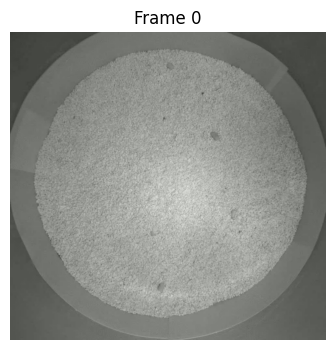

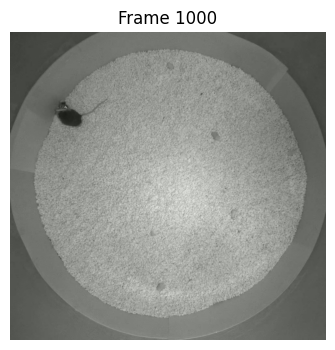

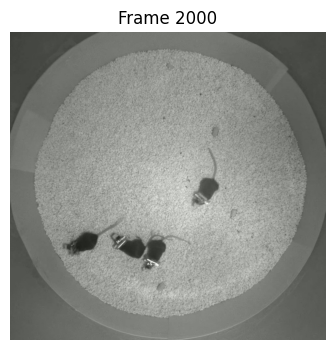

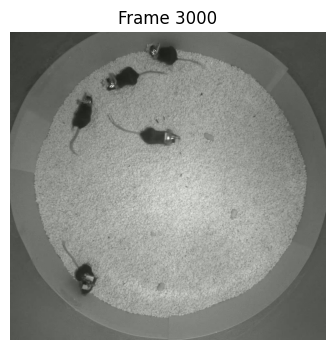

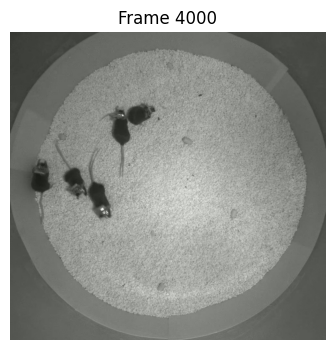

In [ ]:
show_masked_video(
    BOOTSTRAP_SAVE_DIR + "/segmented_video.mp4",
    vis_frame_stride=BATCH_SIZE,
)
